In [1]:
import numpy as np
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "mrpc"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['sentence1', 'sentence2', 'label', 'idx'],
    num_rows: 3668
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence1': 'Amrozi accused his brother , whom he called " the witness " , of deliberately distorting his evidence .',
 'sentence2': 'Referring to him as only " the witness " , Amrozi accused his brother of deliberately distorting his evidence .',
 'label': 1,
 'idx': 0}

In [10]:
raw_train_dataset[5]['sentence1'], raw_train_dataset[5]['sentence2']

('Revenue in the first quarter of the year dropped 15 percent from the same period a year earlier .',
 "With the scandal hanging over Stewart 's company , revenue the first quarter of the year dropped 15 percent from the same period a year earlier .")

In [11]:
raw_train_dataset[5]['label']

1

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'sentence1': Value('string'),
 'sentence2': Value('string'),
 'label': ClassLabel(names=['not_equivalent', 'equivalent']),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1725
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 100]),
 'token_type_ids': torch.Size([32, 100]),
 'attention_mask': torch.Size([32, 100])}

# 4. Load Model

In [19]:
import sys
sys.path.insert(0, '../')

In [20]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [21]:
# id2label, label2id dicts for the outputs for the model
labels = tokenized_datasets["train"].features["labels"].names
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [22]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [24]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(1.2996, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [25]:
device = torch.device("cuda:1") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

device

device(type='cuda', index=1)

### Load Trained Weights

In [26]:
from train_eval_func import eval_loop

In [27]:
len(model.bert.encoder.layer)

12

In [28]:
model.bert.encoder.layer = model.bert.encoder.layer[:5]

In [29]:
len(model.bert.encoder.layer)

5

In [30]:
load_path = './weights/imp_score_merge/layer-5-mrpc.pt'
best_weight = torch.load(load_path, map_location=device)
model.load_state_dict(best_weight['model_state_dict'])

RuntimeError: Error(s) in loading state_dict for BertForSequenceClassification:
	Unexpected key(s) in state_dict: "bert.encoder.layer.0.head_mask_param", "bert.encoder.layer.0.int_mask_param", "bert.encoder.layer.1.head_mask_param", "bert.encoder.layer.1.int_mask_param", "bert.encoder.layer.2.head_mask_param", "bert.encoder.layer.2.int_mask_param", "bert.encoder.layer.3.head_mask_param", "bert.encoder.layer.3.int_mask_param", "bert.encoder.layer.4.head_mask_param", "bert.encoder.layer.4.int_mask_param". 
	size mismatch for bert.encoder.layer.4.attention.self.query.weight: copying a param with shape torch.Size([2304, 768]) from checkpoint, the shape in current model is torch.Size([768, 768]).
	size mismatch for bert.encoder.layer.4.attention.self.query.bias: copying a param with shape torch.Size([2304]) from checkpoint, the shape in current model is torch.Size([768]).
	size mismatch for bert.encoder.layer.4.attention.self.key.weight: copying a param with shape torch.Size([2304, 768]) fr

In [37]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.8578431372549019, 'f1': 0.9016949152542373}

# 5. Similarity Check

In [38]:
from CKA import CKAEvaluator

cka_eval = CKAEvaluator(device)

In [39]:
cls_reps_similarity = cka_eval.pairwise(
    model, 
    train_dataloader, 
    device, 
    only_cls_token=True, 
    max_iter=130
)
stats = cka_eval.similarity_stats(cls_reps_similarity)

print("  Similarity Stats:")
print(f"    Average: {stats['average']:.6f}")
print(f"    Highest: {stats['max']:.6f}")
print(f"    Lowest:  {stats['min']:.6f}")

CKA Evaluation: 100%|██████████| 115/115 [00:03<00:00, 29.32it/s]

  Similarity Stats:
    Average: 0.798303
    Highest: 0.957843
    Lowest:  0.729333


In [40]:
stats

{'average': 0.7983030080795288,
 'max': 0.9578434228897095,
 'argmax': 1,
 'min': 0.7293331027030945,
 'argmin': 4,
 'adj_similarities': [0.7751995, 0.9578434, 0.7727193, 0.7564197, 0.7293331]}

In [41]:
import matplotlib.pyplot as plt
import seaborn as sn

Text(50.722222222222214, 0.5, 'Layer')

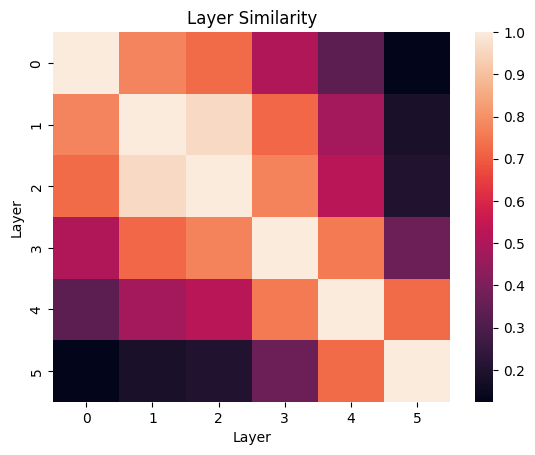

In [42]:
title = "Layer Similarity"
plt.title(title)
sn.heatmap(data = cls_reps_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

In [43]:
from structure_prune_helper import compute_importance_scores

In [44]:
from structure_prune_helper import compute_importance_scores, register_importance_masks, remove_importance_masks

In [45]:
register_importance_masks(model, device, register_heads=True, register_ffn=True)

  Layer 0: Registered masks (12 heads, 3072 neurons)
  Layer 1: Registered masks (12 heads, 3072 neurons)
  Layer 2: Registered masks (12 heads, 3072 neurons)
  Layer 3: Registered masks (12 heads, 3072 neurons)
  Layer 4: Registered masks (12 heads, 3072 neurons)
  Layer 5: Registered masks (12 heads, 3072 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-5): 6 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, e

In [46]:
head_importance, neuron_importance = compute_importance_scores(model, train_dataloader, device, compute_heads=True, compute_ffn=True)

Computing importance (heads + FFN): 100%|██████████| 115/115 [00:07<00:00, 15.76it/s]


In [47]:
head_scores = torch.stack(head_importance).cpu()

# Sum all heads inside each layer
layer_scores = head_scores.sum(dim=1)

print(layer_scores.shape)  # [6]
print(layer_scores)

torch.Size([6])
tensor([4.0577e-05, 4.8770e-05, 4.8390e-05, 4.5001e-05, 3.7328e-05, 2.6641e-05])


In [48]:
normalized_scores = (
    (layer_scores - layer_scores.min())
    / (layer_scores.max() - layer_scores.min())
)
normalized_scores

tensor([0.6297, 1.0000, 0.9828, 0.8296, 0.4829, 0.0000])

In [49]:
import matplotlib.pyplot as plt

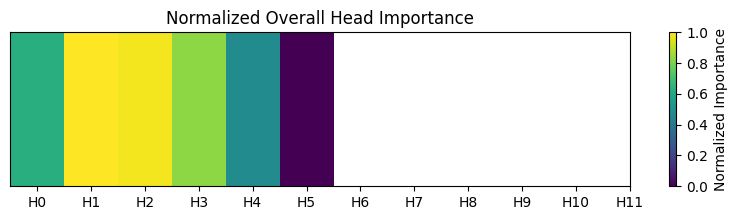

In [50]:
plt.figure(figsize=(10, 2))

im = plt.imshow(
    normalized_scores.unsqueeze(0),
    aspect='auto',
    vmin=0,
    vmax=1
)

plt.colorbar(im, label='Normalized Importance')

plt.xticks(range(12), [f"H{i}" for i in range(12)])
plt.yticks([])

plt.title("Normalized Overall Head Importance")

plt.show()

# 6. Merge Most Similar

In [51]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.8578431372549019, 'f1': 0.9016949152542373}

In [52]:
from structure_prune_helper import compute_importance_scores, register_importance_masks, remove_importance_masks
from layer_merge_helper import merge_mha, merge_ff, reorder_merged_layer_heads, reorder_merged_layer_neurons

In [53]:
register_importance_masks(model, device, register_heads=True, register_ffn=True)

  Layer 0: Registered masks (12 heads, 3072 neurons)
  Layer 1: Registered masks (12 heads, 3072 neurons)
  Layer 2: Registered masks (12 heads, 3072 neurons)
  Layer 3: Registered masks (12 heads, 3072 neurons)
  Layer 4: Registered masks (12 heads, 3072 neurons)
  Layer 5: Registered masks (12 heads, 3072 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-5): 6 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, e

In [54]:
head_importance, neuron_importance = compute_importance_scores(model, train_dataloader, device, compute_heads=True, compute_ffn=True)

Computing importance (heads + FFN): 100%|██████████| 115/115 [00:06<00:00, 17.59it/s]


In [55]:
merge_layer = 4

In [56]:
head_imp1, indices1 = torch.sort(head_importance[merge_layer], descending=True)
head_imp2, indices2 = torch.sort(head_importance[merge_layer+1], descending=True)

neuron_imp1, indices1 = torch.sort(neuron_importance[merge_layer], descending=True)        
neuron_imp2, indices1 = torch.sort(neuron_importance[merge_layer+1], descending=True)

In [57]:
merge_mha(model, model.bert.encoder.layer[merge_layer], model.bert.encoder.layer[merge_layer+1], head_imp1, head_imp2, device, 4)
# merge_ff(model, model.bert.encoder.layer[merge_layer], model.bert.encoder.layer[merge_layer+1], neuron_imp1, neuron_imp2, device, extra_neurons=1024)
    
del model.bert.encoder.layer[merge_layer]

9 7


In [58]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.3161764705882353, 'f1': 0.0}

In [59]:
from torch.optim import AdamW
from train_eval_func import train
from train_eval_func import set_lr_scheduler

In [60]:
optimizer = AdamW(model.parameters(), lr=1e-5)
num_training_steps = 10 * len(train_dataloader)
lr_scheduler = set_lr_scheduler(
    optimizer=optimizer,
    num_training_steps=num_training_steps
)

In [61]:
train_stats = train(
    model,
    train_dataloader,
    val_dataloader,
    task_name,
    device,
    num_epochs=10,
    lr=1e-5,
    patience=3,
    use_early_stopping=True,
    optimizer=optimizer,
    lr_scheduler=lr_scheduler,
    # save_path=temp_save_path,
    display_epoch_iter=True,
    # regression=regression,
    teacher_model=teacher_model, alpha=0.5, temperature=6
)


Training:   0%|          | 0/1150 [00:00<?, ?it/s]

Knowledge distillation used!


/home/abhinavl/work/Layer_Graft/layer-grafting-publication/drop_layer_strategy/../train_eval_func.py:223: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  total_loss += float(loss)
Training:  10%|▉         | 114/1150 [00:11<02:32,  6.77it/s]


<----------------- Epoch 1 ----------------->
Loss: 1.26, Training Metrics:
  accuracy: 0.8653
  f1: 0.9032
Validation Loss: 0.87, Validation Metrics:
  accuracy: 0.8015
  f1: 0.8639
Elapsed Time: 12.6857 sec


Training:  20%|█▉        | 229/1150 [00:24<01:29, 10.30it/s]

...

Training:  30%|███       | 345/1150 [00:37<01:10, 11.44it/s]


<----------------- Epoch 3 ----------------->
Loss: 0.14, Training Metrics:
  accuracy: 0.9836
  f1: 0.9879
Validation Loss: 0.91, Validation Metrics:
  accuracy: 0.8039
  f1: 0.8556
Elapsed Time: 13.2439 sec


Training:  40%|███▉      | 459/1150 [00:50<01:03, 10.94it/s]


<----------------- Epoch 4 ----------------->
Loss: 0.12, Training Metrics:
  accuracy: 0.9877
  f1: 0.9909
Validation Loss: 1.01, Validation Metrics:
  accuracy: 0.8039
  f1: 0.8611
Elapsed Time: 12.627 sec
>>>>> Early stopping callback <<<<<

Total Training Time: 51.52 sec


Training:  40%|████      | 460/1150 [01:03<01:03, 10.94it/s]